In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

100%|██████████| 170M/170M [00:02<00:00, 79.8MB/s]


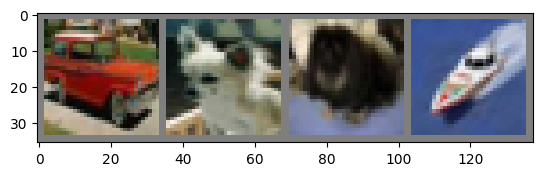

  car   dog   dog  ship


In [ ]:

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ]
)
batch_size = 4
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


def imshow(image):
    image = image / 2 + 0.5
    np_image = image.numpy()
    plt.imshow(np.transpose(np_image, (1, 2, 0)))
    plt.show()

data_iterator = iter(train_loader)
images, labels = next(data_iterator)
imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(batch_size)))



In [ ]:
import torch.nn as nn
import torch.nn.functional as Functional

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 6, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(Functional.relu(self.conv1(x)))
    x = self.pool(Functional.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = Functional.relu(self.fc1(x))
    x = Functional.relu(self.fc2(x))
    x = self.fc3(x)
    return x

net = Net()


In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum= 0.9)

In [ ]:
for epoch in range(2):
  running_loss = 0.0
  for i, data in enumerate(train_loader, 0):
    inputs, labels = data
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    if i%2000 == 1999:
      print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}")
      running_loss = 0.0


print("Finished training")



[1,  2000] loss: 2.241
[1,  4000] loss: 1.866
[1,  6000] loss: 1.685
[1,  8000] loss: 1.592
[1, 10000] loss: 1.543
[1, 12000] loss: 1.490
[2,  2000] loss: 1.398
[2,  4000] loss: 1.380
[2,  6000] loss: 1.366
[2,  8000] loss: 1.310
[2, 10000] loss: 1.304
[2, 12000] loss: 1.284
Finished training


In [ ]:
PATH = './cifar_net.path'
torch.save(net.state_dict(), PATH)

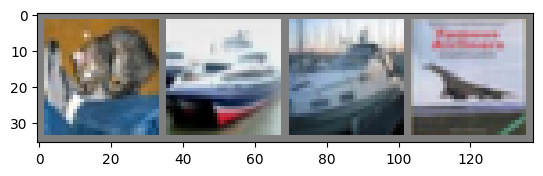

GroundTruth:  cat   ship  ship  plane


In [ ]:
data_iterator_for_test = iter(test_loader)
images, labels = next(data_iterator_for_test)
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f"{classes[labels[j]]:5s}" for j in range(4)))

In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [ ]:
outputs = net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f"{classes[predicted[j]]:5s}" for j in range(4)))

Predicted:  cat   ship  plane ship 


In [ ]:
correct = 0
total = 0
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct //total} %")

Accuracy of the network on the 10000 test images: 55 %


In [ ]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
  for data in test_loader:
    images, labels = data
    outputs = net(images)
    _, predictions = torch.max(outputs, 1)
    for label, prediction in zip(labels, predictions):
      if label == prediction:
        correct_pred[classes[label]] += 1
      total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
  accuracy = 100 * float(correct_count) / total_pred[classname]
  print(f"Accuracy for class: {classname:5s} is {accuracy:1f} %")

Accuracy for class: plane is 62.100000 %
Accuracy for class: car   is 64.800000 %
Accuracy for class: bird  is 55.300000 %
Accuracy for class: cat   is 40.400000 %
Accuracy for class: deer  is 36.800000 %
Accuracy for class: dog   is 34.300000 %
Accuracy for class: frog  is 61.600000 %
Accuracy for class: horse is 67.200000 %
Accuracy for class: ship  is 76.000000 %
Accuracy for class: truck is 52.200000 %
